In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

# Lecture 16 

## Alameda County Jury Panels

We start by showing a table with different ethnicity categories, the proportion of eligible residents of each category, and then we have the actual jury panels that came out of this process. 

In [2]:
jury = Table().with_columns(
    'Ethnicity', make_array('Asian', 'Black', 'Latino', 'White', 'Other'),
    'Eligible', make_array(0.15, 0.18, 0.12, 0.54, 0.01),
    'Panels', make_array(0.26, 0.08, 0.08, 0.54, 0.04)
)

jury

Ethnicity,Eligible,Panels
Asian,0.15,0.26
Black,0.18,0.08
Latino,0.12,0.08
White,0.54,0.54
Other,0.01,0.04


This is very similar to the other jury selection case, where you have the eligible population and the actual panel. 

We try to understand how different are these two, how reasonable is this? 

**Question**   
Rather than looking at these in a table, let's look at this in a chart.  
What is a good chart to use?  - Bar chart! 

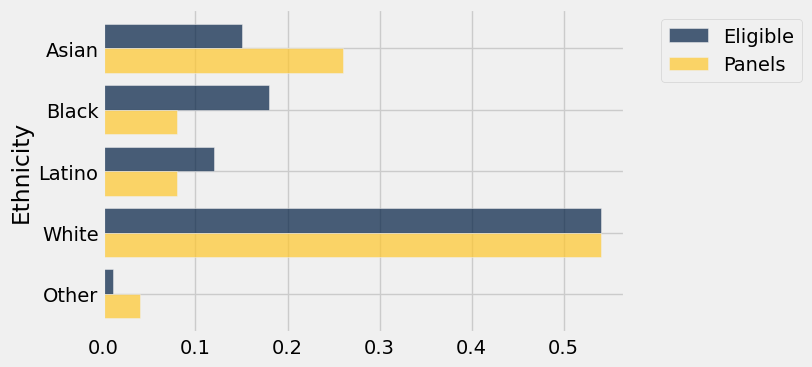

In [3]:
jury.barh('Ethnicity')

We see some differences, more Asians than what are eligible. 
Less Black and Latino, than are eligible. 

But is this reasonable, within the realm of what we might get by chance?

First, we will pull out the proportions of the eligible residents and set this to the model. 

In [4]:
# Under the model, this is the true distribution of people
# from which the jurors are randomly sampled
model = make_array(0.15, 0.18, 0.12, 0.54, 0.01)

Do one simulation.  The sample size was 1423 jurors and we will then use this to sample from the model distribution of eligible people. 

In [5]:
# Let's simulate a random draw of 1423 jurors from this distribution
simulated = sample_proportions(1423, model)
simulated

array([ 0.14476458,  0.15952214,  0.10892481,  0.5699227 ,  0.01686578])

Let's take one of these simulations and add it to the Table. 
It won't tell the whole story but may be easier to compare. 

In [6]:
# The actual observed distribution (Panels) looks quite different
# from the simulation -- try running this several times to confirm!
jury_with_simulated = jury.with_column('Simulated', simulated)
jury_with_simulated

Ethnicity,Eligible,Panels,Simulated
Asian,0.15,0.26,0.144765
Black,0.18,0.08,0.159522
Latino,0.12,0.08,0.108925
White,0.54,0.54,0.569923
Other,0.01,0.04,0.0168658


Let's visualize this as well. 

Generaly, the simulation is close the "eligible", which is what we expect. 

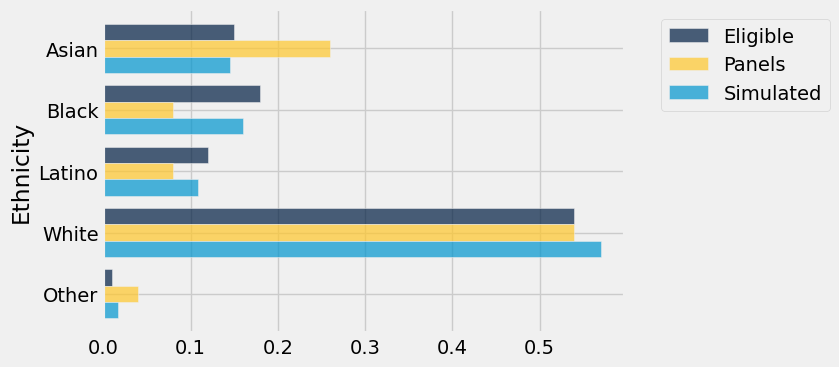

In [7]:
jury_with_simulated.barh('Ethnicity')

This is just for one sample, but to do the simulation repeatedly, we are going to need to keep track of a statistic, a single number. 

So what single number can we use to summarize our data.  How do we summarize the column with a single number? 

This was easy in the last lecture, but how can we do this here. 





## Distance Between Distributions

In [8]:
# In the last lecture, the difference between observed black/purple
# and their expected values (26%/75%) was our statistic.
#
# In this case, we need to understand how each of the 5 categories
# differ from their expected values according to the model.

jury.column('Panels') - jury.column('Eligible')

array([ 0.11, -0.1 , -0.04,  0.  ,  0.03])

In [9]:
diffs = jury.column('Panels') - jury.column('Eligible')
jury_with_difference = jury.with_column('Difference', diffs)
jury_with_difference

Ethnicity,Eligible,Panels,Difference
Asian,0.15,0.26,0.11
Black,0.18,0.08,-0.1
Latino,0.12,0.08,-0.04
White,0.54,0.54,0
Other,0.01,0.04,0.03


This is moving in the right direction, but it is still five numbers. 

What are some other ideas (how can we use the diffs)?  

In [10]:
# Idea 1: Take the average 
np.average(diffs)

5.551115123125783e-18

This is a really small number, essentially zero. 

Why?
 - Errors in opposite directions are cancelling each other out.
 - each column is a proportion and each column must sum to one.  
   subtracting them is going to get 0. 

In [11]:
# Idea 2: Sum the Absolute Difference 
abs(diffs)

array([ 0.11,  0.1 ,  0.04,  0.  ,  0.03])

In [12]:
sum(abs(diffs))

0.28000000000000003

In [13]:
# We can do the same thing with the simulated. 
sum(abs(jury_with_simulated.column('Simulated') - jury.column('Eligible')))

0.073576950105411112

We might not have a great intuition yet on what these values mean, but we have a single value that can be used as a statistic. 

<br><br><br><br>

---

<center> return to slides </center>

---

<br><br>

## Total Variation Distance

Let's do the whole process here again: 

* Choose a statistic to measure “discrepancy” between model and data  
  We did **Total Variation Distance**

First, let's make a function to calculate the total variation distance between two distributions. 





In [14]:
def tvd(dist1, dist2):
    return sum(abs(dist1 - dist2))/2

We can use this function to look at TVD. 

In [15]:
# The TVD of our observed data (Panels) from their expected values
# assuming the model is true (Eligbible)
obsvd_tvd = tvd(jury.column('Panels'), jury.column('Eligible'))
obsvd_tvd

0.14000000000000001

In [16]:
# The TVD of a model simluation from its expected values
tvd(sample_proportions(1423, model), jury.column('Eligible'))

0.024061841180604355

Next, 

* Simulate the statistic under the model’s assumptions  
Create a function that samples from the model, then calculates the *TVD* between the simulated sample and the model.


In [17]:
def simulated_tvd():
    return tvd(sample_proportions(1423, model), model)

tvds = make_array()

num_simulations = 10000
for i in np.arange(num_simulations):
    new_tvd = simulated_tvd()
    tvds = np.append(tvds, new_tvd)

* Compare the data to the model’s predictions:
    * Draw a histogram of simulated values of the statistic
    * Compute the observed statistic from the real sample
* If the observed statistic is far from the histogram, that is evidence against the model

Observed TVD: 0.14


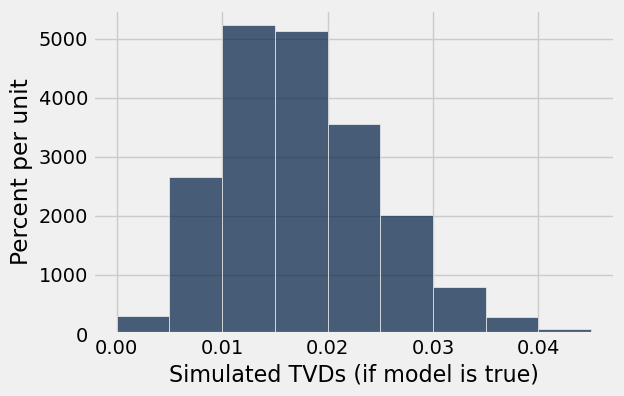

In [18]:
title = 'Simulated TVDs (if model is true)'
bins = np.arange(0, .05, .005)

Table().with_column(title, tvds).hist(bins = bins)
print('Observed TVD: ' + str(obsvd_tvd))

We don't have a good intuition on this statistic, but we can see the average is ~0.015, a max of < 0.05. 

But the observed is 0.14. 

Our conclusion is that we have evidence against our model (conclude the alternative viewpoint). 




<br><br><br><br>

---

<center> return to slides </center>

---

<br><br>